---
title: 'Classification and Logistic Regression'
---

In [1]:
import numpy as np
from scipy.fft import fft, ifft, fftshift
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import pickle
from copy import copy
%matplotlib inline

It is pretty typical that given some data set, say $\left\{{\bf x}_{j}\right\}_{j=1}^{N_{D}}$ that we might want to *classify* or *label* the data.  The simplest example of this would be sorting the data into two distinct bins, numerically denoted by a variable $y\in\left\{0,1\right\}$.  This lets us say whether something is a species of flower or not, dog or cat, true or false.  Whatever *property*/*not-property* dichotomy that matters to you can be framed this way.  While this kind of question is pretty natural, that we frame everything in probabilistic terms from here on out is maybe not as obvious.  The point though is that we only imagine that a machine is capable of learning class distinction via probability, i.e., it is very likely that a cat is not a dog is something we think a computer can manage.  Maybe that is also how our brains work, but who knows (we really don't).

So, the go-to probabilistic model for a two-state random variable $Y$ is the *Bernoulli*-distribution.  Introducing the parameter $\theta$ where $0<\theta<1$, if we say $Y \sim \text{Ber}(\theta)$ then 

$$
\mathbb{P}(Y=1) = \theta, ~\mathbb{P}(Y=0) = 1-\theta.
$$

This has a corresponding distribution funciton $\text{ber}(y|\theta)=\theta^{y}(1-\theta)^{1-y}$.

*Problem*: Show that $\sum_{y=0}^{1}\text{ber}(y|\theta)=1$.

*Problem*: Show that $\mathbb{E}[Y]=\theta$.  

Not too bad; certainly easier than messing with Gaussians.  But now we want to ask a more challening question.  Suppose I give you labeled training data $\left\{({\bf x}_{j}, y_{j})\right\}_{j=1}^{N_{D}}$.  Now, I want you to model this data via a probability distribution 

$$
p(y|{\bf x},{\bf w},b) = \text{ber}(y|\sigma(\left<{\bf w},{\bf x}\right>+b)), ~ \sigma(x) = \frac{1}{1+e^{-x}}.
$$

Here, the *sigmoid* function $\sigma(x)$ is introduced.  

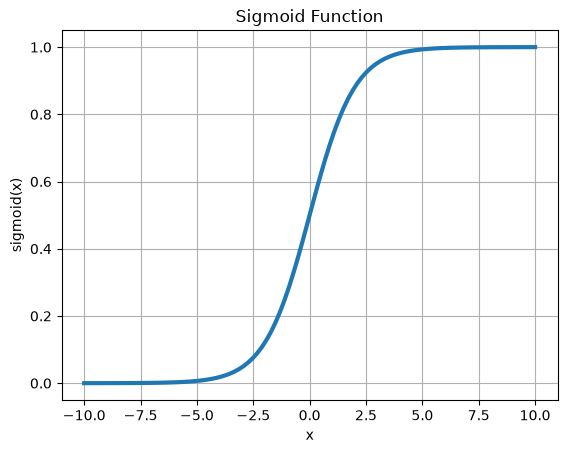

In [5]:
# Plot of the Sigmoid

sigmoid = lambda x: 1 / (1 + np.exp(-x))
x = np.linspace(-10, 10, 100)
plt.plot(x, sigmoid(x),lw=3)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()

So what's going on here?  As we see, the sigmoid $\sigma(x)$ is transforming $\left<{\bf w},{\bf x}\right>+b$ into something between 0 and 1 and thus something that can serve as an approximation to the average.  Noting that $\sigma(0)=1/2$, we see then that the corresponding (hyper)plane

$$
\left<{\bf w},{\bf x}\right>+b = 0
$$

gives us the surface over which we have exactly even odds of $y$ being $0$ or $1$.  Those points ${\bf x}$ such that $\left<{\bf w},{\bf x}\right>+b > 0$ are more likely to correspond to $y=1$ and vice versa.  Thus we call our plane $\left<{\bf w},{\bf x}\right>+b = 0$ a *decision boundary*.  

So with that bit of setup, we now need to figure out how to take training data and find ${\bf w}$ and $b$.  Again, we use a Maximum Likelihood Estimation (MLE) approach by introducing the log-likelihood function $\mathcal{L}({\bf w},b)$ where 

\begin{align*}
\mathcal{L}({\bf w},b) = & \sum_{j=1}^{N_{D}}\log \left(\text{ber}\left(y_{j}|\sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right)\right)\\
= & \sum_{j=1}^{N_{D}}y_{j}\log \left(\sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right) + (1-y_{j})\log \left(1-\sigma(\left<{\bf w},{\bf x}_{j}\right>+b)\right)
\end{align*}

*Problem*: From the above, show that 

$$
\mathcal{L}({\bf w},b) = -\sum_{j=1}^{N_{D}}(1-y_{j}) \left(\left<{\bf w},{\bf x}_{j}\right>+b\right) + \log\left(1+e^{- \left(\left<{\bf w},{\bf x}_{j}\right>+b\right)}\right)
$$

*Problem*: Show that 

$$
\nabla_{{\bf w}}\mathcal{L} = \sum_{j=1}^{N_{D}}{\bf x}_{j}\left(y_{j} - \sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right)
$$

and

$$
\frac{\partial \mathcal{L}}{\partial b} = \sum_{j=1}^{N_{D}}\left(y_{j} - \sigma\left(\left<{\bf w},{\bf x}_{j}\right>+b\right)\right).
$$

So, clearly trying to set these equal to zero and solving is not really going to work.  Thus, we need another method for finding the optimal choices $({\bf w}_{\ast},b_{\ast})$ so that 

\begin{align*}
({\bf w}_{\ast},b_{\ast}) = & \text{arg max}_{({\bf w},b)}\mathcal{L}({\bf w},b)\\
= & \text{arg min}_{({\bf w},b)}\left(-\mathcal{L}({\bf w},b)\right)
\end{align*}